## 1. 导入和配置

In [1]:
import sys
from pathlib import Path

# 确保 stats_utils 可导入
sys.path.insert(0, str(Path(".").resolve()))
from stats_utils import *

setup_plotting()

# 输出路径
OUTPUT_PATH = BASE_PATH / "reports" / "comparison" / "frequency_roi"
OUTPUT_PATH, FIGURES_PATH = ensure_output_dirs(OUTPUT_PATH)

print(f"输出目录: {OUTPUT_PATH}")
print(f"图片目录: {FIGURES_PATH}")

输出目录: d:\LYW\REST_COM\reports\comparison\frequency_roi
图片目录: d:\LYW\REST_COM\reports\comparison\frequency_roi\figures


## 2. 数据加载

In [2]:
import pandas as pd

def load_frequency_data() -> pd.DataFrame:
    """加载三组频域数据 (subject_band_powers.csv)"""
    dfs = []
    for g in GROUPS:
        csv_path = FREQ_PATHS[g] / 'subject_band_powers.csv'
        if csv_path.exists():
            df = pd.read_csv(csv_path)
            df['group'] = g
            dfs.append(df)
            print(f'  {GROUP_LABELS[g]}: {len(df)} 被试')
        else:
            print(f'  ⚠ 未找到: {csv_path}')
    if not dfs:
        return pd.DataFrame()
    return pd.concat(dfs, ignore_index=True)


print('--- 加载频域数据 ---')
freq_df = load_frequency_data()
print(f'\n频域数据: {freq_df.shape}')
freq_df.head()

--- 加载频域数据 ---
  ADHD单纯组: 12 被试
  ADHD共患阅读困难组: 14 被试
  正常发展组: 8 被试

频域数据: (34, 7)


,subject_id,group,Delta,Theta,Alpha,Beta,Gamma
0,18,adhd,2.813040e-11,3.262314e-12,1.681465e-12,2.464228e-13,6.749327e-14
1,29,adhd,1.199479e-11,5.302395e-12,1.799600e-12,3.183868e-13,8.900980e-14
2,31,adhd,1.109306e-11,1.293141e-12,4.601824e-13,1.975893e-13,1.647121e-13
3,37,adhd,2.466549e-11,1.037310e-11,4.341498e-12,1.448976e-12,8.100163e-13
4,38,adhd,9.824419e-12,3.154986e-12,2.931533e-12,4.089642e-13,2.397410e-13


## 3. Omnibus 检验

In [3]:
print('=' * 60)
print('频域指标 Omnibus 检验')
print('=' * 60)

freq_results = []
if not freq_df.empty:
    for band in FREQ_BANDS:
        if band not in freq_df.columns:
            continue
        res = run_analysis_for_metric(freq_df, band, 'band_power', freq_band=band)
        if res:
            freq_results.append(res)
            sig_mark = '***' if res['p'] < 0.001 else '**' if res['p'] < 0.01 else '*' if res['p'] < 0.05 else ''
            print(f"  {band:<8s} | {res['test']:<16s} | "
                  f"p={res['p']:.4f} {sig_mark:>3s} | {res['es_name']}={res['effect_size']:.3f}")

print(f'\n频域检验总数: {len(freq_results)}')

频域指标 Omnibus 检验
  Delta    | Kruskal-Wallis   | p=0.5463     | ε²=-0.026
  Theta    | Kruskal-Wallis   | p=0.5517     | ε²=-0.026
  Alpha    | Kruskal-Wallis   | p=0.8592     | ε²=-0.055
  Beta     | Kruskal-Wallis   | p=0.8739     | ε²=-0.056
  Gamma    | Kruskal-Wallis   | p=0.5812     | ε²=-0.030

频域检验总数: 5


## 4. FDR 校正

In [4]:
freq_omnibus_df = apply_fdr(freq_results)

if not freq_omnibus_df.empty:
    print('频域 Omnibus 结果 (FDR 校正后):')
    print(freq_omnibus_df[['metric', 'freq_band', 'test', 'p', 'p_fdr', 'significant', 'effect_size']].to_string(index=False))

# 汇总事后检验
posthoc_df = collect_posthoc(freq_results)

if not posthoc_df.empty:
    print('\n事后检验结果 (仅 omnibus 显著指标):')
    print(posthoc_df[['metric', 'freq_band', 'pair', 'test', 'p', 'cohens_d', 'significant']].to_string(index=False))

# 保存 CSV
freq_omnibus_df.to_csv(OUTPUT_PATH / 'frequency_omnibus_stats.csv', index=False, encoding='utf-8-sig')
if not posthoc_df.empty:
    posthoc_df.to_csv(OUTPUT_PATH / 'posthoc_stats.csv', index=False, encoding='utf-8-sig')
print('\n✓ 统计结果已保存')

频域 Omnibus 结果 (FDR 校正后):
    metric freq_band           test        p    p_fdr  significant  effect_size
band_power     Delta Kruskal-Wallis 0.546314 0.873931        False    -0.025512
band_power     Theta Kruskal-Wallis 0.551652 0.873931        False    -0.026139
band_power     Alpha Kruskal-Wallis 0.859185 0.873931        False    -0.054724
band_power      Beta Kruskal-Wallis 0.873931 0.873931        False    -0.055822
band_power     Gamma Kruskal-Wallis 0.581225 0.873931        False    -0.029509

✓ 统计结果已保存


## 5. 可视化

In [5]:
# 频域箱线图
if not freq_df.empty:
    for band in FREQ_BANDS:
        if band in freq_df.columns:
            plot_boxplots(freq_df, band,
                          f'{band} 频段功率', f'{band} Power (μV²/Hz)',
                          FIGURES_PATH / f'boxplot_freq_{band}.png')
    print('✓ 频域箱线图已保存')

✓ 频域箱线图已保存


In [6]:
# 效应量森林图
plot_effect_sizes(posthoc_df, FIGURES_PATH / 'effect_sizes_forest.png')

# 显著性热图
plot_significance_heatmap(freq_omnibus_df, '频域指标 Omnibus p 值 (FDR)',
                          FIGURES_PATH / 'heatmap_freq_significance.png')
print('✓ 可视化完成')

  无显著事后检验结果, 跳过森林图
✓ 可视化完成


## 6. 生成报告

In [7]:
# 描述性统计
desc_sections = ['### 频域指标\n']
if not freq_df.empty:
    for band in FREQ_BANDS:
        if band in freq_df.columns:
            desc_sections.append(f'**{band}:**\n')
            desc_sections.append(format_desc_table(freq_df, band))
desc_text = '\n'.join(desc_sections)

# Omnibus 表格
omnibus_text = format_omnibus_table(freq_omnibus_df, '频域指标')

# 事后检验表格
posthoc_text = format_posthoc_table(posthoc_df)

# 样本量
sample_sizes = {g: len(freq_df[freq_df['group'] == g]) for g in GROUPS}

report = generate_report(
    title='频域功率组间统计比较报告',
    analysis_desc='频域功率: Delta, Theta, Alpha, Beta, Gamma (5 检验)',
    sample_sizes=sample_sizes,
    desc_text=desc_text,
    omnibus_text=omnibus_text,
    posthoc_text=posthoc_text,
)

report_file = OUTPUT_PATH / 'frequency_comparison_report.md'
with open(report_file, 'w', encoding='utf-8') as f:
    f.write(report)
print(f'✓ 报告已保存: {report_file}')

✓ 报告已保存: d:\LYW\REST_COM\reports\comparison\frequency_roi\frequency_comparison_report.md


## 7. 分析完成

In [8]:
print('=' * 60)
print('频域功率统计分析完成!')
print('=' * 60)

print(f'\n输出文件:')
for f in sorted(OUTPUT_PATH.glob('*')):
    if f.is_file():
        print(f'  - {f.name}')

print(f'\n可视化文件:')
for f in sorted(FIGURES_PATH.glob('*.png')):
    print(f'  - {f.name}')

# 显著结果摘要
print('\n' + '=' * 60)
print('显著结果摘要 (FDR < 0.05)')
print('=' * 60)

if not freq_omnibus_df.empty:
    sig = freq_omnibus_df[freq_omnibus_df['significant']]
    print(f'\n频域功率: {len(sig)}/{len(freq_omnibus_df)} 项显著')
    if len(sig) > 0:
        print(sig[['metric', 'freq_band', 'p_fdr', 'effect_size']].to_string(index=False))
    else:
        print('  无显著结果')

频域功率统计分析完成!

输出文件:
  - frequency_comparison_report.md
  - frequency_omnibus_stats.csv
  - roi_lme_results.csv

可视化文件:
  - boxplot_freq_Alpha.png
  - boxplot_freq_Beta.png
  - boxplot_freq_Delta.png
  - boxplot_freq_Gamma.png
  - boxplot_freq_Theta.png
  - heatmap_freq_significance.png
  - roi_pvalue_heatmap_adhd.png
  - roi_pvalue_heatmap_com.png

显著结果摘要 (FDR < 0.05)

频域功率: 0/5 项显著
  无显著结果


## 8. ROI Trial-level 数据加载

**目标:** 加载每个被试每个trial在各ROI的频段功率

**数据结构:** `[subject_id, group, trial_idx, roi, band, power, log_power]`

**ROI定义:**
- Frontal: 前额叶（执行功能）
- Central: 中央区（运动控制）
- Parietal: 顶叶（注意网络）
- Occipital: 枕叶（视觉处理）
- Temporal: 颞叶（听觉/记忆）

In [9]:
import mne
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# 定义ROI
ROI_CHANNELS = {
    "frontal": ["Fp1", "Fp2", "F3", "F4", "F7", "F8", "Fz", "FC1", "FC2", "FC5", "FC6"],
    "central": ["C3", "C4", "Cz", "CP1", "CP2", "CP5", "CP6"],
    "parietal": ["P3", "P4", "Pz", "P7", "P8", "PO3", "PO4"],
    "occipital": ["O1", "O2", "Oz", "PO7", "PO8"],
    "temporal": ["T7", "T8", "TP9", "TP10", "FT9", "FT10"]
}

BANDS = {"Delta": (0.5, 4), "Theta": (4, 8), "Alpha": (8, 13), "Beta": (13, 30), "Gamma": (30, 45)}
EPOCH_DATA_PATH = BASE_PATH / "preprocessing" / "data" / "6epoch_clean"

SUBJECT_GROUPS = {}
for group in GROUPS:
    group_path = EPOCH_DATA_PATH / group
    if group_path.exists():
        SUBJECT_GROUPS[group] = [f.stem.replace("-epo", "") for f in group_path.glob("*-epo.fif")]

print("被试分组:")
for g in GROUPS:
    print(f"  {GROUP_LABELS[g]}: {len(SUBJECT_GROUPS[g])} 被试")

print("ROI定义:")
for roi, channels in ROI_CHANNELS.items():
    print(f"  {roi}: {len(channels)} 通道")

被试分组:
  ADHD单纯组: 12 被试
  ADHD共患阅读困难组: 14 被试
  正常发展组: 8 被试
ROI定义:
  frontal: 11 通道
  central: 7 通道
  parietal: 7 通道
  occipital: 5 通道
  temporal: 6 通道


In [10]:
def load_roi_trial_data():
    """加载ROI-level trial数据"""
    all_trials = []
    
    for group in GROUPS:
        print(f"加载 {GROUP_LABELS[group]}...")
        for subject_id in SUBJECT_GROUPS[group]:
            epoch_file = EPOCH_DATA_PATH / group / f"{subject_id}-epo.fif"
            if not epoch_file.exists():
                continue
            
            epochs = mne.read_epochs(epoch_file, preload=True, verbose=False)
            psd = epochs.compute_psd(method="welch", fmin=0.5, fmax=45, verbose=False)
            psds, freqs = psd.get_data(return_freqs=True)
            
            for trial_idx in range(len(epochs)):
                for roi_name, roi_channels in ROI_CHANNELS.items():
                    roi_indices = [i for i, ch in enumerate(epochs.ch_names) if ch in roi_channels]
                    if len(roi_indices) == 0:
                        continue
                    
                    for band_name, (fmin, fmax) in BANDS.items():
                        freq_mask = (freqs >= fmin) & (freqs < fmax)
                        power = psds[trial_idx, roi_indices, :][:, freq_mask].mean()
                        all_trials.append({
                            "subject_id": subject_id,
                            "group": group,
                            "trial_idx": trial_idx,
                            "roi": roi_name,
                            "band": band_name,
                            "power": power,
                            "log_power": np.log10(power + 1e-20)
                        })
            
            print(f"  {subject_id}: {len(epochs)} trials")
    
    return pd.DataFrame(all_trials)

trial_df_roi = load_roi_trial_data()
print(f"总数据点: {len(trial_df_roi)}")
print(f"被试数: {trial_df_roi['subject_id'].nunique()}")
print(f"ROI数: {trial_df_roi['roi'].nunique()}")
print(f"频段数: {trial_df_roi['band'].nunique()}")
print(f"数据预览:")
trial_df_roi.head(10)

加载 ADHD单纯组...
  018: 19 trials
  029: 22 trials
  031: 19 trials
  037: 25 trials
  038: 30 trials
  045: 19 trials
  075: 26 trials
  091: 23 trials
  094: 30 trials
  117: 28 trials
  132: 17 trials
  134: 19 trials
加载 ADHD共患阅读困难组...
  001: 24 trials
  020: 22 trials
  021: 24 trials
  022: 18 trials
  024: 22 trials
  047: 19 trials
  049: 20 trials
  051: 27 trials
  072: 27 trials
  073: 26 trials
  076: 17 trials
  092: 15 trials
  113: 29 trials
  150: 21 trials
加载 正常发展组...
  006: 23 trials
  068: 23 trials
  079: 28 trials
  093: 26 trials
  108: 23 trials
  109: 19 trials
  127: 17 trials
  133: 24 trials
总数据点: 19275
被试数: 34
ROI数: 5
频段数: 5
数据预览:


,subject_id,group,trial_idx,roi,band,power,log_power
0,018,adhd,0,frontal,Delta,2.366198e-11,-10.625949
1,018,adhd,0,frontal,Theta,1.980294e-12,-11.703270
2,018,adhd,0,frontal,Alpha,2.617324e-12,-11.582143
3,018,adhd,0,frontal,Beta,2.149379e-13,-12.667687
4,018,adhd,0,frontal,Gamma,5.051464e-14,-13.296583
5,018,adhd,0,central,Delta,1.095967e-11,-10.960202
6,018,adhd,0,central,Theta,1.501314e-12,-11.823529
7,018,adhd,0,central,Alpha,2.240936e-12,-11.649571
8,018,adhd,0,central,Beta,1.607136e-13,-12.793947
9,018,adhd,0,central,Gamma,3.479917e-14,-13.458431


## 9. ROI LME 分析

**模型:** `log_power ~ C(group, Treatment("td")) + (1|subject_id)`

对每个ROI × Band组合分别做LME分析（5 ROI × 5 Band = 25次检验）

In [11]:
import statsmodels.formula.api as smf

lme_results_roi = {}
roi_summary = []

for roi in ROI_CHANNELS.keys():
    print("=" * 70)
    print(f"ROI: {roi.upper()}")
    print("=" * 70)
    
    lme_results_roi[roi] = {}
    
    for band in BANDS.keys():
        roi_band_df = trial_df_roi[(trial_df_roi['roi'] == roi) & (trial_df_roi['band'] == band)].copy()
        
        model = smf.mixedlm("log_power ~ C(group, Treatment('td'))",
                           data=roi_band_df,
                           groups=roi_band_df["subject_id"],
                           re_formula="~1")
        result = model.fit(method="lbfgs")
        
        var_between = result.cov_re.iloc[0, 0]
        var_within = result.scale
        icc = var_between / (var_between + var_within)
        
        lme_results_roi[roi][band] = {"result": result, "icc": icc}
        
        print(f"\n{band}:")
        for param in result.fe_params.index:
            if "group" in param and "Intercept" not in param:
                beta = result.fe_params[param]
                se = result.bse_fe[param]
                p = result.pvalues[param]
                group_name = "ADHD" if "adhd" in param.lower() else "COM"
                sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
                print(f"  {group_name} vs TD: β={beta:.4f}, p={p:.4f} {sig}")
                
                roi_summary.append({
                    "roi": roi,
                    "band": band,
                    "comparison": f"{group_name} vs TD",
                    "beta": beta,
                    "se": se,
                    "p": p,
                    "icc": icc
                })
        print(f"  ICC: {icc:.3f}")

roi_summary_df = pd.DataFrame(roi_summary)
print(f"\n总检验数: {len(roi_summary_df)}")


ROI: FRONTAL

Delta:
  ADHD vs TD: β=0.1529, p=0.3094 
  COM vs TD: β=0.0978, p=0.5032 
  ICC: 0.682

Theta:
  ADHD vs TD: β=0.1034, p=0.3380 
  COM vs TD: β=0.0467, p=0.6558 
  ICC: 0.738

Alpha:
  ADHD vs TD: β=0.0050, p=0.9701 
  COM vs TD: β=-0.0057, p=0.9647 
  ICC: 0.795

Beta:
  ADHD vs TD: β=0.0718, p=0.5535 
  COM vs TD: β=0.0172, p=0.8836 
  ICC: 0.787

Gamma:
  ADHD vs TD: β=0.1272, p=0.3357 
  COM vs TD: β=0.0106, p=0.9344 
  ICC: 0.550
ROI: CENTRAL

Delta:
  ADHD vs TD: β=0.0684, p=0.5618 
  COM vs TD: β=0.0241, p=0.8333 
  ICC: 0.584

Theta:
  ADHD vs TD: β=0.0785, p=0.4537 
  COM vs TD: β=0.0491, p=0.6296 
  ICC: 0.774

Alpha:
  ADHD vs TD: β=-0.0104, p=0.9375 
  COM vs TD: β=0.0138, p=0.9145 
  ICC: 0.765

Beta:
  ADHD vs TD: β=0.0386, p=0.7441 
  COM vs TD: β=0.0097, p=0.9325 
  ICC: 0.821

Gamma:
  ADHD vs TD: β=0.1189, p=0.4396 
  COM vs TD: β=-0.0404, p=0.7869 
  ICC: 0.698
ROI: PARIETAL

Delta:
  ADHD vs TD: β=0.0603, p=0.6036 
  COM vs TD: β=0.0078, p=0.9447 
  IC

## 10. FDR 校正

对50次检验（5 ROI × 5 Band × 2 Comparison）进行FDR校正

In [12]:
from statsmodels.stats.multitest import multipletests

roi_summary_df["p_fdr"] = multipletests(roi_summary_df["p"], method="fdr_bh")[1]
roi_summary_df['significant'] = roi_summary_df["p_fdr"] < 0.05

print("FDR校正后显著结果:")
sig_results = roi_summary_df[roi_summary_df['significant']]
if len(sig_results) > 0:
    print(sig_results[["roi", "band", "comparison", "beta", "p", "p_fdr"]].to_string(index=False))
else:
    print("  无显著结果")

print(f"\n显著结果数: {len(sig_results)}/{len(roi_summary_df)}")

roi_summary_df.to_csv(OUTPUT_PATH / "roi_lme_results.csv", index=False, encoding="utf-8-sig")
print("\n✓ ROI LME结果已保存")

FDR校正后显著结果:
  无显著结果

显著结果数: 0/50

✓ ROI LME结果已保存


## 11. 可视化

生成热图和森林图展示ROI分析结果

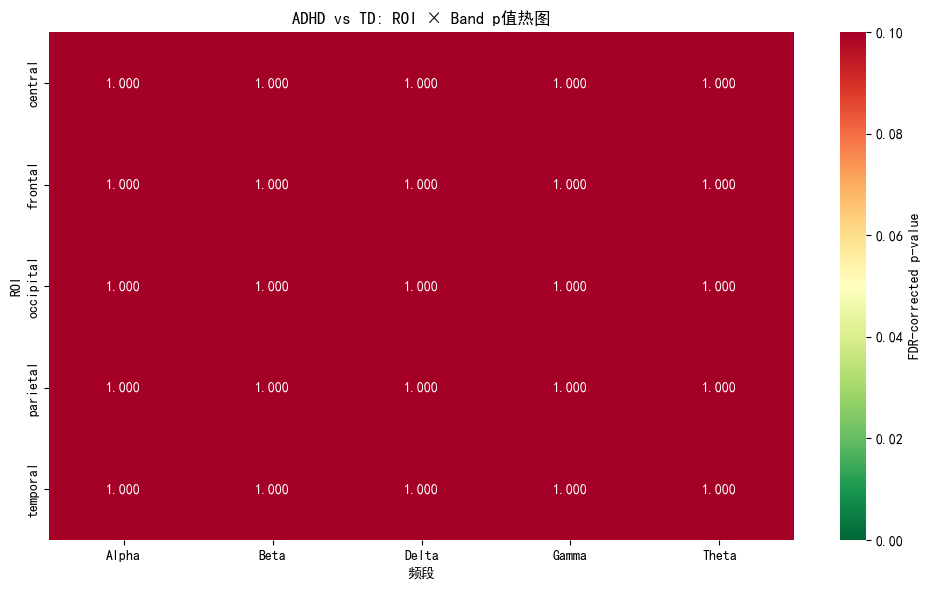

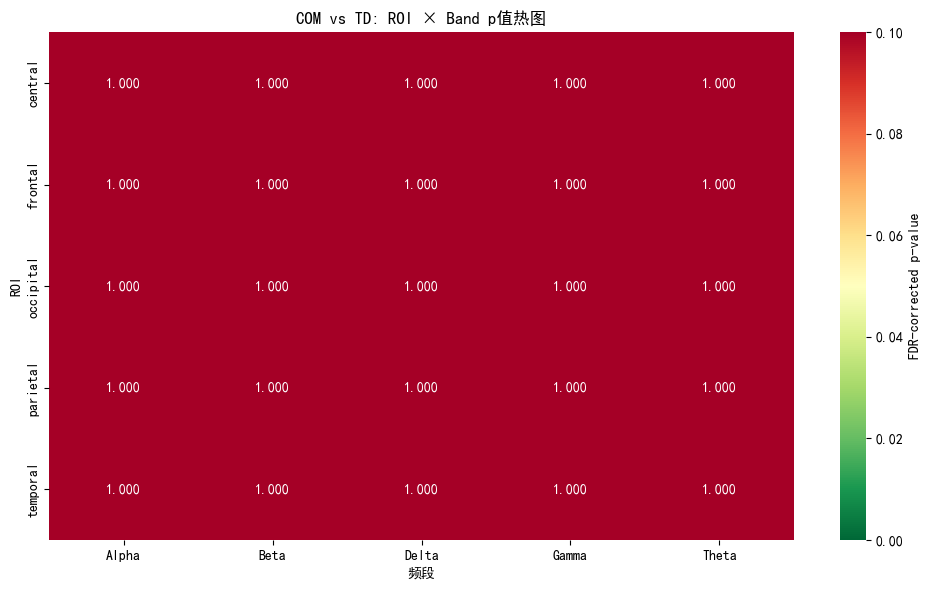

✓ 热图已保存


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. p值热图（ADHD vs TD）
adhd_results = roi_summary_df[roi_summary_df['comparison'] == "ADHD vs TD"].copy()
p_matrix = adhd_results.pivot(index="roi", columns="band", values="p_fdr")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(p_matrix, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.1,
            cbar_kws={"label": "FDR-corrected p-value"}, ax=ax)
ax.set_title("ADHD vs TD: ROI × Band p值热图")
ax.set_xlabel("频段")
ax.set_ylabel("ROI")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "roi_pvalue_heatmap_adhd.png", dpi=300, bbox_inches="tight")
plt.show()

# 2. p值热图（COM vs TD）
com_results = roi_summary_df[roi_summary_df['comparison'] == "COM vs TD"].copy()
p_matrix_com = com_results.pivot(index="roi", columns="band", values="p_fdr")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(p_matrix_com, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=0.1,
            cbar_kws={"label": "FDR-corrected p-value"}, ax=ax)
ax.set_title("COM vs TD: ROI × Band p值热图")
ax.set_xlabel("频段")
ax.set_ylabel("ROI")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "roi_pvalue_heatmap_com.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ 热图已保存")

In [14]:
# 3. 森林图（仅显著结果）
if len(sig_results) > 0:
    fig, ax = plt.subplots(figsize=(10, max(6, len(sig_results) * 0.4)))
    
    y_pos = range(len(sig_results))
    y_labels = [f"{row['roi']} {row['band']} ({row['comparison']})" 
                for _, row in sig_results.iterrows()]
    betas = sig_results["beta"].values
    ses = sig_results["se"].values
    
    ax.errorbar(betas, y_pos, xerr=1.96*ses, fmt="o", capsize=5, markersize=8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("β系数 (95% CI)")
    ax.set_title("显著ROI效应森林图")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / "roi_forest_plot.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("✓ 森林图已保存")
else:
    print("无显著结果，跳过森林图")

无显著结果，跳过森林图


## 12. 综合报告

In [15]:
print("=" * 70)
print("ROI分析结果总结")
print("=" * 70)

print(f"\n总检验数: {len(roi_summary_df)}")
print(f"显著结果数 (FDR < 0.05): {len(sig_results)}")

if len(sig_results) > 0:
    print("\n显著发现:")
    for _, row in sig_results.iterrows():
        direction = "增加" if row['beta'] > 0 else "降低"
        print(f"  - {row['roi'].upper()} {row['band']}: {row['comparison']} {direction} (β={row['beta']:.4f}, p_fdr={row['p_fdr']:.4f})")
else:
    print("\n未发现显著的ROI特异性组间差异")

print("\n按ROI汇总:")
for roi in ROI_CHANNELS.keys():
    roi_sig = sig_results[sig_results['roi'] == roi]
    print(f"  {roi.upper()}: {len(roi_sig)} 个显著结果")

print("\n按频段汇总:")
for band in BANDS.keys():
    band_sig = sig_results[sig_results['band'] == band]
    print(f"  {band}: {len(band_sig)} 个显著结果")

print("\n分析完成！")

ROI分析结果总结

总检验数: 50
显著结果数 (FDR < 0.05): 0

未发现显著的ROI特异性组间差异

按ROI汇总:
  FRONTAL: 0 个显著结果
  CENTRAL: 0 个显著结果
  PARIETAL: 0 个显著结果
  OCCIPITAL: 0 个显著结果
  TEMPORAL: 0 个显著结果

按频段汇总:
  Delta: 0 个显著结果
  Theta: 0 个显著结果
  Alpha: 0 个显著结果
  Beta: 0 个显著结果
  Gamma: 0 个显著结果

分析完成！
